In [1]:

from shapely.geometry import Point, LineString, Polygon
from shapely import geometry as geo
import pyclipper


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.0.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "d:\anaconda\envs\pt\lib\runpy.py", line 197, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "d:\anaconda\envs\pt\lib\runpy.py", line 87, in _run_code
    exec(code, run_globals)
  File "d:\anaconda\envs\pt\lib\site-packages\ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "d:\anaconda\envs\pt\lib\site-packages\traitlets\config\application.py", line 1075, in launch_instance
    app.start()
  File "d:\anaconda\envs\pt\lib\site-packages\ipykernel\kernelapp

AttributeError: _ARRAY_API not found

ImportError: numpy.core.multiarray failed to import

True


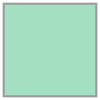

In [ ]:
  # 定义一个多边形（注意，Shapely需要点列表是环形的，即第一个和最后一个点应该是相同的）  
points = [(0, 0), (1, 0), (1, 1), (0, 1), (0, 0)]  # 这是一个简单的矩形  
polygon = Polygon(points)  
  
print(polygon.is_simple)  # 应该输出 True  
polygon

True


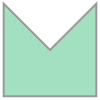

In [ ]:
# 定义一个非简单的多边形（例如，有自交的边）  
points_non_simple = [(0, 0), (1, 0), (1, 1), (0.5, 0.5), (0, 1), (0, 0)]  
polygon_non_simple = Polygon(points_non_simple)  
  
print(polygon_non_simple.is_simple)  # 应该输出 False
polygon_non_simple

# 文本检测评价指标

In [ ]:
#!/usr/bin/env python
# -*- coding: utf-8 -*-
from collections import namedtuple
import numpy as np
from shapely.geometry import Polygon
"""
reference from :
https://github.com/MhLiao/DB/blob/3c32b808d4412680310d3d28eeb6a2d5bf1566c5/concern/icdar2015_eval/detection/iou.py#L8
"""


class DetectionIoUEvaluator(object):
    def __init__(self, iou_constraint=0.5, area_precision_constraint=0.5):
        """
        iou_constraint: 检测box 与 真实 box 的IoU > iou_constraint 就认为是匹配上了
        area_precision_constraint: 检测box 与 要忽略的真实box 的交集 / 检测box的面积 > area_precision_constraint ,则该检测box就 被认为是 不用被关注的 检测box
        """
        self.iou_constraint = iou_constraint
        self.area_precision_constraint = area_precision_constraint

    def evaluate_image(self, gt, pred):
        def get_union(pD, pG):
            return Polygon(pD).union(Polygon(pG)).area

        def get_intersection_over_union(pD, pG):
            return get_intersection(pD, pG) / get_union(pD, pG)

        def get_intersection(pD, pG):
            return Polygon(pD).intersection(Polygon(pG)).area

        def compute_ap(confList, matchList, numGtCare):
            correct = 0
            AP = 0
            if len(confList) > 0:
                confList = np.array(confList)
                matchList = np.array(matchList)
                sorted_ind = np.argsort(-confList)
                confList = confList[sorted_ind]
                matchList = matchList[sorted_ind]
                for n in range(len(confList)):
                    match = matchList[n]
                    if match:
                        correct += 1
                        AP += float(correct) / (n + 1)

                if numGtCare > 0:
                    AP /= numGtCare

            return AP

        perSampleMetrics = {}

        matchedSum = 0

        Rectangle = namedtuple('Rectangle', 'xmin ymin xmax ymax')

        numGlobalCareGt = 0
        numGlobalCareDet = 0

        arrGlobalConfidences = []
        arrGlobalMatches = []

        recall = 0
        precision = 0
        hmean = 0

        detMatched = 0

        iouMat = np.empty([1, 1])

        gtPols = []
        detPols = []

        gtPolPoints = []
        detPolPoints = []

        # Array of Ground Truth Polygons' keys marked as don't Care
        gtDontCarePolsNum = []
        # Array of Detected Polygons' matched with a don't Care GT
        detDontCarePolsNum = []

        pairs = []
        detMatchedNums = []

        arrSampleConfidences = []
        arrSampleMatch = []

        evaluationLog = ""

        for n in range(len(gt)):        # 遍历每一个真实的经过人工标注的定位框!!
            points = gt[n]['points']    # [(0, 0), (1, 0), (1, 1), (0, 1), (0, 1), (0, 1), (0, 1)]
            dontCare = gt[n]['ignore']  # 一般情况都为 False， 意思是都需要关注-->Care， 不能忽略-->ignore
            if not Polygon(points).is_valid:
                continue

            gtPol = points
            gtPols.append(gtPol)
            gtPolPoints.append(points) # 并没有什么用途
            if dontCare:
                gtDontCarePolsNum.append(len(gtPols) - 1)  # 记录下 要忽略的gt-box的index位置

        evaluationLog += "GT polygons: " + str(len(gtPols)) + (
            " (" + str(len(gtDontCarePolsNum)) + " don't care)\n"
            if len(gtDontCarePolsNum) > 0 else "\n")

        for n in range(len(pred)):     # 遍历 每一个预测框
            points = pred[n]['points']
            if not Polygon(points).is_valid:
                continue

            detPol = points
            detPols.append(detPol)
            detPolPoints.append(points)  # 并没有什么用途
            if len(gtDontCarePolsNum) > 0:
                for dontCarePol in gtDontCarePolsNum:   # 遍历所有的 要忽略的 真实box
                    dontCarePol = gtPols[dontCarePol]
                    intersected_area = get_intersection(dontCarePol, detPol) # 计算 该预测框 与 该要忽略的真实框 的 交集面积
                    pdDimensions = Polygon(detPol).area  # 该检测框的面积
                    precision = 0 if pdDimensions == 0 else intersected_area / pdDimensions  # 交集面积/检测框的面积
                    if (precision > self.area_precision_constraint):  # 只要检测框的 > 0.5 以内的面积 in gt 区域内， 就被认为是有效的区域面积
                        detDontCarePolsNum.append(len(detPols) - 1)   # 记录下 与 要忽略的gt匹配上的  检测框的 index 位置
                        break

        evaluationLog += "DET polygons: " + str(len(detPols)) + (
            " (" + str(len(detDontCarePolsNum)) + " don't care)\n"
            if len(detDontCarePolsNum) > 0 else "\n")
        # ---------------------------------------------------- 以下才是关键的核心代码 --------------------------------------------------------- # 
        if len(gtPols) > 0 and len(detPols) > 0:
            # Calculate IoU and precision matrixs
            outputShape = [len(gtPols), len(detPols)]  # [2, 1] ----> 表示 gt-box 的数量是2， det-box的数量为1
            iouMat = np.empty(outputShape)
            gtRectMat = np.zeros(len(gtPols), np.int8)   # array([0, 0], dtype=int8)
            detRectMat = np.zeros(len(detPols), np.int8) # array([0], dtype=int8)
            for gtNum in range(len(gtPols)):
                for detNum in range(len(detPols)):
                    pG = gtPols[gtNum]
                    pD = detPols[detNum]
                    iouMat[gtNum, detNum] = get_intersection_over_union(pD, pG)  # 计算所有的 gt-box 与 所有的 det-box 之间  IoU

            for gtNum in range(len(gtPols)):
                for detNum in range(len(detPols)):
                    if gtRectMat[gtNum] == 0 and detRectMat[
                            detNum] == 0 and gtNum not in gtDontCarePolsNum and detNum not in detDontCarePolsNum:
                        if iouMat[gtNum, detNum] > self.iou_constraint:
                            gtRectMat[gtNum] = 1    # 表示 该 gt已经被 匹配上了
                            detRectMat[detNum] = 1  # 表示 该 det已经被 匹配上了
                            detMatched += 1
                            pairs.append({'gt': gtNum, 'det': detNum})
                            detMatchedNums.append(detNum)
                            evaluationLog += "Match GT #" + \
                                             str(gtNum) + " with Det #" + str(detNum) + "\n"

        numGtCare = (len(gtPols) - len(gtDontCarePolsNum))
        numDetCare = (len(detPols) - len(detDontCarePolsNum))
        # if numGtCare == 0:
        #     recall = float(1)
        #     precision = float(0) if numDetCare > 0 else float(1)
        # else:
        #     recall = float(detMatched) / numGtCare  # 计算召回率
        #     precision = 0 if numDetCare == 0 else float(detMatched) / numDetCare  # 计算准确率

        # hmean = 0 if (precision + recall) == 0 else 2.0 * \
        #                                             precision * recall / (precision + recall)

        matchedSum += detMatched
        numGlobalCareGt += numGtCare
        numGlobalCareDet += numDetCare

        perSampleMetrics = {
            'gtCare': numGtCare,
            'detCare': numDetCare,
            'detMatched': detMatched,
        }
        return perSampleMetrics

    def combine_results(self, results):
        numGlobalCareGt = 0
        numGlobalCareDet = 0
        matchedSum = 0
        for result in results:
            numGlobalCareGt += result['gtCare']
            numGlobalCareDet += result['detCare']
            matchedSum += result['detMatched']

        methodRecall = 0 if numGlobalCareGt == 0 else float(
            matchedSum) / numGlobalCareGt
        methodPrecision = 0 if numGlobalCareDet == 0 else float(
            matchedSum) / numGlobalCareDet
        methodHmean = 0 if methodRecall + methodPrecision == 0 else 2 * \
                                                                    methodRecall * methodPrecision / (
                                                                            methodRecall + methodPrecision)
        methodMetrics = {
            'precision': methodPrecision,
            'recall': methodRecall,
            'hmean': methodHmean
        }

        return methodMetrics


if __name__ == '__main__':
    evaluator = DetectionIoUEvaluator()
    gts = [[{
        'points': [(0, 0), (1, 0), (1, 1), (0, 1), (0, 1), (0, 1), (0, 1)],
        'text': 1234,
        'ignore': False,
    }, {
        'points': [(2, 2), (3, 2), (3, 3), (2, 3)],
        'text': 5678,
        'ignore': False,
    }]]
    preds = [[{
        'points': [(0.1, 0.1), (1, 0), (1, 1), (0, 1)],
        'text': 123,
        'ignore': False,
    }]]
    results = []
    for gt, pred in zip(gts, preds):
        results.append(evaluator.evaluate_image(gt, pred))
    metrics = evaluator.combine_results(results)
    print(metrics)


{'precision': 1.0, 'recall': 0.5, 'hmean': 0.6666666666666666}
